# (연구) HST example 3

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [논문연구]

### import 

In [1]:
import matplotlib.pyplot as plt 
import mpl_toolkits.mplot3d.art3d as art3d
import numpy as np

### 현재환경

In [2]:
!conda env list

# conda environments:
#
base                     /home/cgb3/anaconda3
py39r40               *  /home/cgb3/anaconda3/envs/py39r40



### 예제설정 

In [3]:
V=['V1','V2','V3','V4']
f=[2,1,3,4]
x=[-1/np.sqrt(2),0,1,0]
y=[-1/np.sqrt(2),0,0,1]
W=[[0,1,0,0],
   [1,0,1,1],
   [0,1,0,0],
   [0,1,0,0]]

### HST 

In [4]:
%run heavysnow 

In [5]:
gs=GraphSignal(V,W,f)
hst=HeavysnowTransform(gs)
hst.snow(tau=12,b=1,maxflow=16)

HST (tau= 12, b=1)
12/12
HST completed and all history is recorded.


In [6]:
trace = [V[k] for k in hst.trajectory]
print(trace)

['V2', 'V2', 'V2', 'V3', 'V2', 'V3', 'V2', 'V1', 'V4', 'V2', 'V1', 'V2', 'V4']


### 시각화 

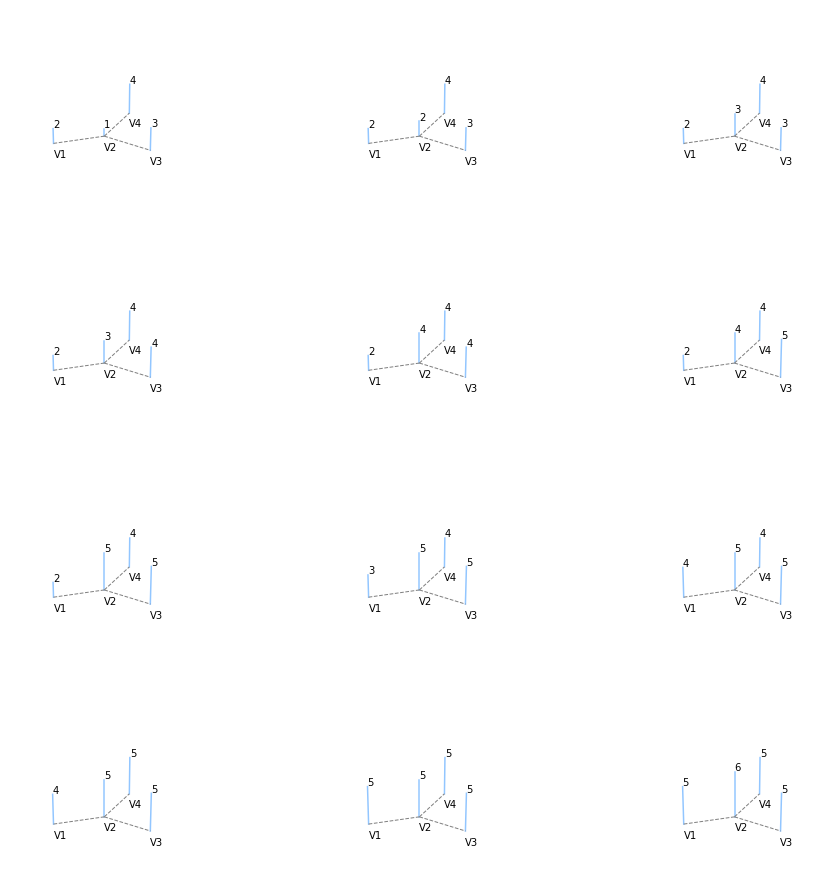

In [7]:
with plt.style.context('seaborn-pastel'): 
    fig = plt.figure(figsize=(16,16))
    for k in range(12):
        ax = fig.add_subplot(4, 3, k+1, projection='3d')
        _i=1
        for xi, yi, fi in zip(x, y, hst.snowygrounds[:,k]):
            line=art3d.Line3D(*zip((xi, yi, 0), (xi, yi, fi)))
            ax.add_line(line)
            #_col= hst.trajectory[3]+1
            ax.text(xi,yi,-2, 'V'+str(_i))
            _i=_i+1
            ax.text(xi,yi,fi+0.1, str(fi))  
        for start in range(4): 
            for end in range(start,4):
                if(W[start][end]==1):
                    line2=art3d.Line3D(
                        *zip((x[start],y[start],0),(x[end],y[end],0)),
                        linestyle='dashed',
                        color='gray',
                        linewidth=1
                    )
                    ax.add_line(line2)
        ax.set_xlim3d(-1.1, 1.1)
        ax.set_ylim3d(-1.1, 1.1)
        ax.set_zlim3d(0, 10)    
        ax.set_yticks(ticks= [])
        ax.set_xticks(ticks= [])
        ax.set_zticks(ticks= [])
        # Get rid of the panes
        ax.w_xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax.w_yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax.w_zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        # Get rid of the spines
        ax.w_xaxis.line.set_color((1.0, 1.0, 1.0, 0.0))
        ax.w_yaxis.line.set_color((1.0, 1.0, 1.0, 0.0))
        ax.w_zaxis.line.set_color((1.0, 1.0, 1.0, 0.0))
    plt.show()

In [8]:
fig.savefig('2022-02-12-illustration_of_HSprocess.pdf', transparent=True)